In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [3]:
holdings = pd.read_excel('FIN 499P ETF PROJECT DASH-XLF.xlsx', sheet_name='10 holdings Adj Close Data', header=1)
xlf = pd.read_excel('FIN 499P ETF PROJECT DASH-XLF.xlsx', sheet_name='XLF OHLC 22-26', header=0)

xlf = xlf.rename(columns={'Close\xa0': 'Close', 'Adj Close\xa0': 'Adj Close'})

print(holdings.shape, xlf.shape)
holdings.head()
                    

(1002, 11) (1003, 12)


,Date,JPM Adj Close,BRK-B Adj Close,Visa-Adj Close,MA-Adj Close,BAC-Adj Close,GS-Adj Close,WFC-Adj Close,MS-Adj Close,Citi-Adj Close,SCHW-Adj Close
0,2022-09-13,105.64,278.29,193.61,317.70,30.75,298.21,39.06,76.64,42.79,68.96
1,2022-09-14,105.39,278.42,193.36,318.10,30.63,297.18,39.12,76.75,42.29,68.77
2,2022-09-15,106.98,276.70,189.44,309.42,31.21,301.14,39.89,77.70,42.30,68.61
3,2022-09-16,106.26,274.81,187.43,307.63,30.86,296.23,39.71,76.97,42.01,67.94
4,2022-09-19,107.24,278.95,187.27,306.56,31.38,298.45,40.06,78.11,42.12,69.68


In [4]:
rename_map = {
    'JPM Adj Close\xa0' : 'JPM',
    'BRK-B Adj Close\xa0' : 'BRK-B',
    'Visa-Adj Close ' : 'Visa',
    'MA-Adj Close': 'MA',
    'BAC-Adj Close': 'BAC',
    'GS-Adj Close': 'GS',
    'WFC-Adj Close': 'WFC',
    'MS-Adj Close': 'MS',
    'Citi-Adj Close': 'Citi',
    'SCHW-Adj Close': 'SCHW'

}

holdings = holdings.rename(columns=rename_map)
print(holdings.columns.tolist())

tickers = ['JPM', 'BRK-B', 'Visa', 'MA', 'BAC', 'GS', 'WFC', 'MS', 'Citi', 'SCHW']

['Date', 'JPM', 'BRK-B', 'Visa', 'MA', 'BAC', 'GS', 'WFC', 'MS', 'Citi', 'SCHW']


In [5]:
holdings['Date'] = pd.to_datetime(holdings['Date'])

xlf = xlf[['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].copy()
xlf['Date'] = pd.to_datetime(xlf['Date'])

xlf.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-09-13,33.96,34.08,33.24,33.35,31.15,60771600
1,2022-09-14,33.42,33.58,32.95,33.25,31.05,39233200
2,2022-09-15,33.29,33.79,33.20,33.36,31.16,47653000
3,2022-09-16,33.03,33.12,32.71,33.06,30.88,53893300
4,2022-09-19,32.50,33.28,32.50,33.26,31.23,36491400


In [6]:
holdings[tickers].isna().sum()

JPM      0
BRK-B    0
Visa     0
MA       0
BAC      0
GS       0
WFC      0
MS       0
Citi     0
SCHW     0
dtype: int64

In [7]:
duplicate_count = holdings['Date'].duplicated().sum()
print('Number of duplicate date rows:', duplicate_count)


Number of duplicate date rows: 15


In [8]:
holdings = holdings.drop_duplicates(subset='Date', keep='first')

holdings[tickers] = holdings[tickers].interpolate(method='linear', limit_direction='both')

holdings[tickers].isna().sum()

JPM      0
BRK-B    0
Visa     0
MA       0
BAC      0
GS       0
WFC      0
MS       0
Citi     0
SCHW     0
dtype: int64

In [9]:
holdings_by_date = holdings.set_index('Date')
returns = holdings_by_date[tickers].pct_change()

xlf_by_date = xlf.set_index('Date')
xlf_returns = xlf_by_date['Adj Close'].pct_change()

returns.head()

,JPM,BRK-B,Visa,MA,BAC,GS,WFC,MS,Citi,SCHW
Date,,,,,,,,,,
2022-09-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-14,-0.002367,0.000467,-0.001291,0.001259,-0.003902,-0.003454,0.001536,0.001435,-0.011685,-0.002755
2022-09-15,0.015087,-0.006178,-0.020273,-0.027287,0.018936,0.013325,0.019683,0.012378,0.000236,-0.002327
2022-09-16,-0.006730,-0.006831,-0.010610,-0.005785,-0.011214,-0.016305,-0.004512,-0.009395,-0.006856,-0.009765
2022-09-19,0.009223,0.015065,-0.000854,-0.003478,0.016850,0.007494,0.008814,0.014811,0.002618,0.025611


In [10]:
price_correlation = holdings_by_date[tickers].corr()
return_correlation = returns.corr()

price_correlation

,JPM,BRK-B,Visa,MA,BAC,GS,WFC,MS,Citi,SCHW
JPM,1.000000,0.914733,0.931732,0.906347,0.966298,0.961027,0.979421,0.942832,0.948659,0.864713
BRK-B,0.914733,1.000000,0.950718,0.953943,0.835732,0.808071,0.901609,0.772174,0.779372,0.693965
Visa,0.931732,0.950718,1.000000,0.977351,0.851680,0.822801,0.924660,0.800629,0.801233,0.755324
MA,0.906347,0.953943,0.977351,1.000000,0.818909,0.770133,0.904203,0.738785,0.743546,0.714447
BAC,0.966298,0.835732,0.851680,0.818909,1.000000,0.966559,0.963197,0.957254,0.954464,0.913774
GS,0.961027,0.808071,0.822801,0.770133,0.966559,1.000000,0.934340,0.992667,0.992216,0.876271
WFC,0.979421,0.901609,0.924660,0.904203,0.963197,0.934340,1.000000,0.913906,0.917918,0.894241
MS,0.942832,0.772174,0.800629,0.738785,0.957254,0.992667,0.913906,1.000000,0.988407,0.868718
Citi,0.948659,0.779372,0.801233,0.743546,0.954464,0.992216,0.917918,0.988407,1.000000,0.867531
SCHW,0.864713,0.693965,0.755324,0.714447,0.913774,0.876271,0.894241,0.868718,0.867531,1.000000


In [11]:
return_correlation

,JPM,BRK-B,Visa,MA,BAC,GS,WFC,MS,Citi,SCHW
JPM,1.000000,0.000342,0.245362,0.436223,0.315879,0.243326,0.468729,0.513749,0.529981,0.262181
BRK-B,0.000342,1.000000,0.067565,-0.002470,0.103821,0.086749,0.038970,0.008890,0.041179,0.044468
Visa,0.245362,0.067565,1.000000,0.529618,0.344420,0.309469,0.364216,0.340758,0.372054,0.287603
MA,0.436223,-0.002470,0.529618,1.000000,0.202600,0.177158,0.269264,0.319864,0.326633,0.193290
BAC,0.315879,0.103821,0.344420,0.202600,1.000000,0.682731,0.626490,0.495073,0.574234,0.451018
GS,0.243326,0.086749,0.309469,0.177158,0.682731,1.000000,0.538120,0.570219,0.537896,0.402410
WFC,0.468729,0.038970,0.364216,0.269264,0.626490,0.538120,1.000000,0.602402,0.684590,0.502114
MS,0.513749,0.008890,0.340758,0.319864,0.495073,0.570219,0.602402,1.000000,0.731943,0.461865
Citi,0.529981,0.041179,0.372054,0.326633,0.574234,0.537896,0.684590,0.731943,1.000000,0.406983
SCHW,0.262181,0.044468,0.287603,0.193290,0.451018,0.402410,0.502114,0.461865,0.406983,1.000000


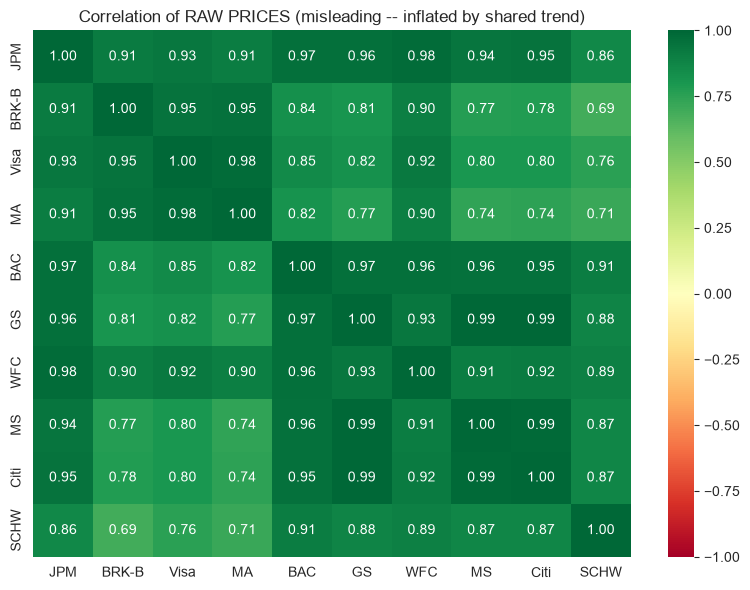

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(price_correlation, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Correlation of RAW PRICES (misleading -- inflated by shared trend)')
plt.tight_layout()
plt.savefig('correlation_prices.png', dpi=120)
plt.show()

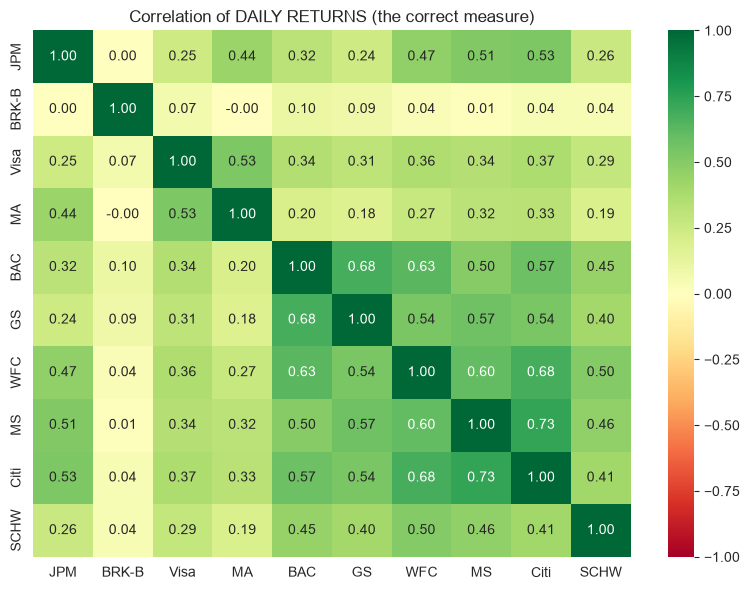

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(return_correlation, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Correlation of DAILY RETURNS (the correct measure)')
plt.tight_layout()
plt.savefig('correlation_returns.png', dpi=120)
plt.show()

In [15]:
growth_factors = 1 + returns.fillna(0)
cumulative_growth = growth_factors.cumprod() * 100

xlf_growth_factors = 1 + xlf_returns.fillna(0)
xlf_cumulative_growth = xlf_growth_factors.cumprod() * 100

cumulative_growth.head()

,JPM,BRK-B,Visa,MA,BAC,GS,WFC,MS,Citi,SCHW
Date,,,,,,,,,,
2022-09-13,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2022-09-14,99.763347,100.046714,99.870874,100.125905,99.609756,99.654606,100.153610,100.143528,98.831503,99.724478
2022-09-15,101.268459,99.428654,97.846186,97.393768,101.495935,100.982529,102.124936,101.383090,98.854873,99.492459
2022-09-16,100.586899,98.749506,96.808016,96.830343,100.357724,99.336038,101.664107,100.430585,98.177144,98.520882
2022-09-19,101.514578,100.237163,96.725376,96.493547,102.048780,100.080480,102.560164,101.918058,98.434214,101.044084


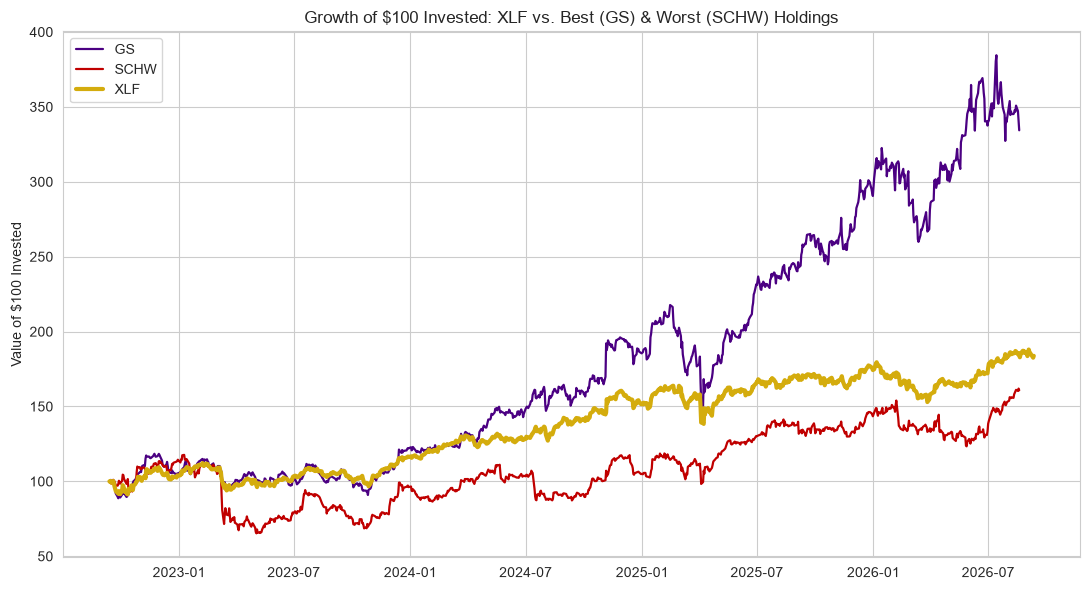

In [16]:
plt.figure(figsize=(11, 6))
plt.plot(cumulative_growth.index, cumulative_growth['GS'], label='GS', color='#4B0082', linewidth=1.6)
plt.plot(cumulative_growth.index, cumulative_growth['SCHW'], label='SCHW', color='#C00000', linewidth=1.6)
plt.plot(xlf_cumulative_growth.index, xlf_cumulative_growth.values, label='XLF', color='#D4AC0D', linewidth=3)

plt.title('Growth of $100 Invested: XLF vs. Best (GS) & Worst (SCHW) Holdings')
plt.ylabel('Value of $100 Invested')
plt.legend()
plt.tight_layout()
plt.savefig('cumulative_growth.png', dpi=120)
plt.show()

In [17]:
risk_free_rate = 0.051

annualized_return = returns.mean() * 252
annualized_volatility = returns.std() * np.sqrt(252)
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

summary = pd.DataFrame({
    'Annualized Return': annualized_return,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratio
})

summary

,Annualized Return,Annualized Volatility,Sharpe Ratio
JPM,0.338568,0.232739,1.235581
BRK-B,0.168840,0.166190,0.709069
Visa,0.182825,0.202003,0.652591
MA,0.172435,0.206416,0.588303
BAC,0.209920,0.254794,0.623720
GS,0.349575,0.286773,1.041155
WFC,0.241290,0.282021,0.674739
MS,0.303175,0.284390,0.886725
Citi,0.331519,0.288644,0.971851
SCHW,0.169655,0.309489,0.383390


In [18]:
xlf_annualized_return = xlf_returns.mean() * 252
xlf_annualized_volatility = xlf_returns.std() * np.sqrt(252)
xlf_sharpe_ratio = (xlf_annualized_return - risk_free_rate) / xlf_annualized_volatility

summary.loc['XLF'] = [xlf_annualized_return, xlf_annualized_volatility, xlf_sharpe_ratio]

summary = summary.sort_values('Sharpe Ratio', ascending=False)
summary

,Annualized Return,Annualized Volatility,Sharpe Ratio
JPM,0.338568,0.232739,1.235581
GS,0.349575,0.286773,1.041155
Citi,0.331519,0.288644,0.971851
MS,0.303175,0.284390,0.886725
BRK-B,0.168840,0.166190,0.709069
XLF,0.167624,0.170452,0.684203
WFC,0.241290,0.282021,0.674739
Visa,0.182825,0.202003,0.652591
BAC,0.209920,0.254794,0.623720
MA,0.172435,0.206416,0.588303


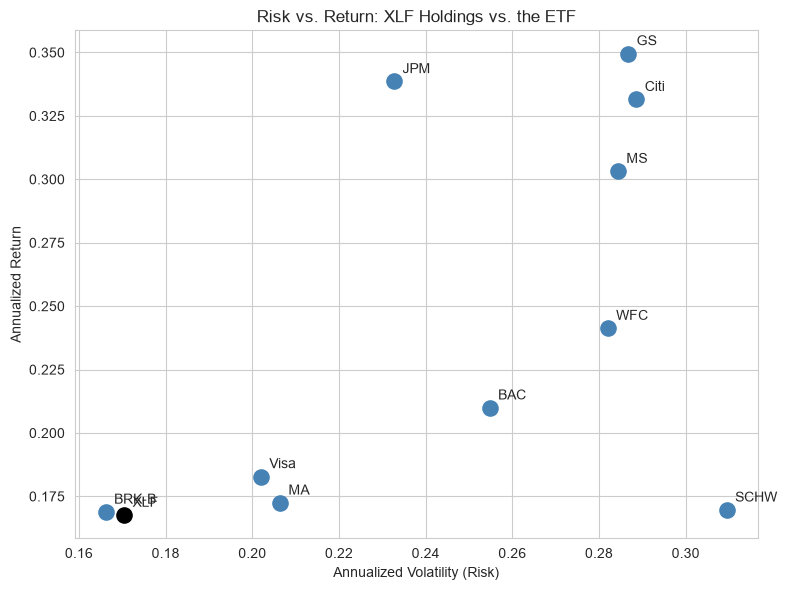

In [19]:
plt.figure(figsize=(8, 6))

for ticker in summary.index:
    risk = summary.loc[ticker, 'Annualized Volatility']
    ret = summary.loc[ticker, 'Annualized Return']
    color = 'black' if ticker == 'XLF' else 'steelblue'
    plt.scatter(risk, ret, s=120, color=color)
    plt.annotate(ticker, (risk, ret), textcoords='offset points', xytext=(6, 6))

plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.title('Risk vs. Return: XLF Holdings vs. the ETF')
plt.tight_layout()
plt.savefig('risk_return_scatter.png', dpi=120)
plt.show()

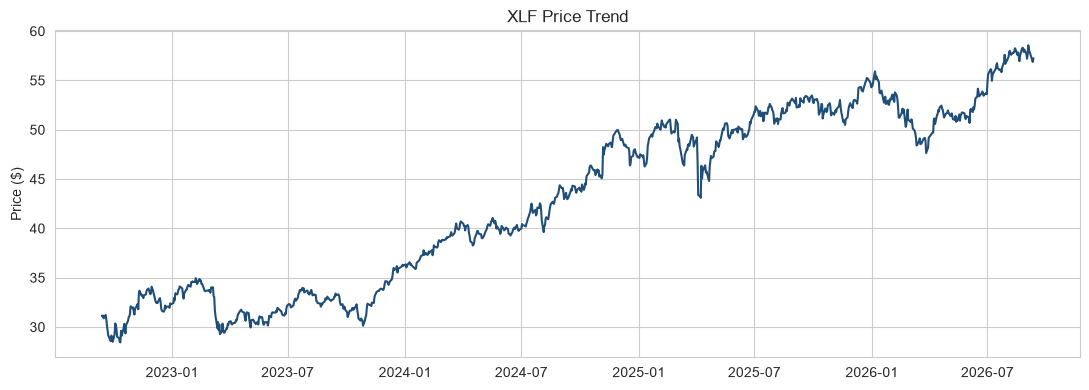

In [20]:
plt.figure(figsize=(11, 4))
plt.plot(xlf['Date'], xlf['Adj Close'], color='#1F4E78')
plt.title('XLF Price Trend')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.savefig('xlf_price.png', dpi=120)
plt.show()

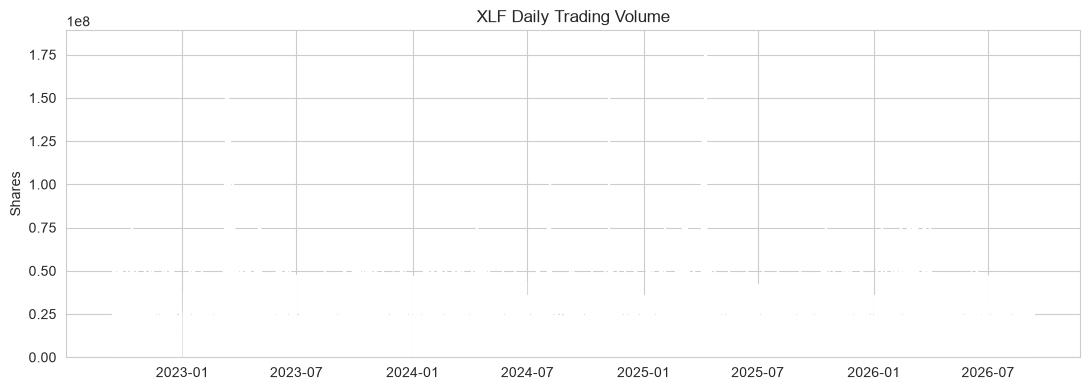

In [21]:
plt.figure(figsize=(11, 4))
plt.bar(xlf['Date'], xlf['Volume'], color='#9DC3E6', width=1.5)
plt.title('XLF Daily Trading Volume')
plt.ylabel('Shares')
plt.tight_layout()
plt.savefig('xlf_volume.png', dpi=120)
plt.show()

In [22]:
xlf['Volume'].describe()

count    1.003000e+03
mean     4.280567e+07
std      1.772854e+07
min      1.126650e+07
25%      3.230405e+07
50%      3.914060e+07
75%      4.852975e+07
max      1.799932e+08
Name: Volume, dtype: float64

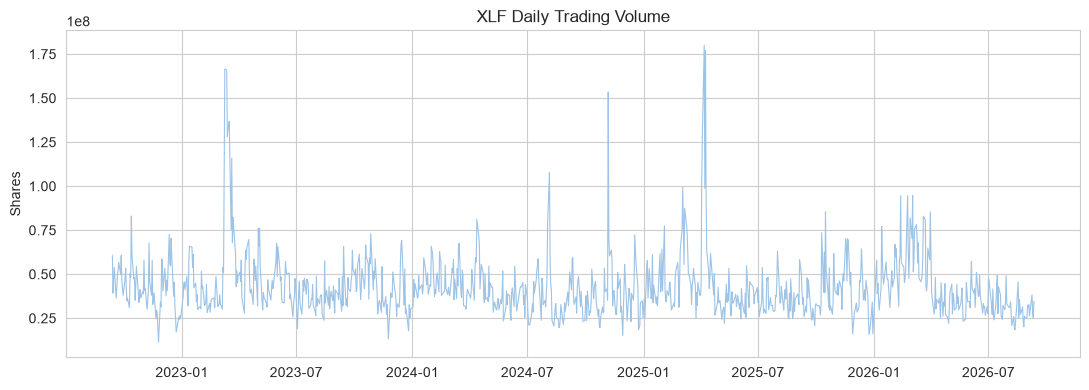

In [23]:
plt.figure(figsize=(11, 4))
plt.plot(xlf['Date'], xlf['Volume'], color='#9DC3E6', linewidth=0.8)
plt.title('XLF Daily Trading Volume')
plt.ylabel('Shares')
plt.tight_layout()
plt.savefig('xlf_volume.png', dpi=120)
plt.show()